In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
macro_recall = 0.8192968874787057
macro_f1 = 0.8035697316615443
confusion_matrix = np.array([[164, 8, 62], [1, 211, 30], [2, 15, 131]])

classification_report = {
    'normal': {
        'precision': 0.9820359281437125, 
        'recall': 0.7008547008547008, 
        'f1-score': 0.8179551122194514, 
        'support': 234.0},
    'bacterial': {
        'precision': 0.9017094017094017, 
        'recall': 0.871900826446281, 
        'f1-score': 0.8865546218487395, 
        'support': 242.0},
    'viral': {
        'precision': 0.5874439461883408, 
        'recall': 0.8851351351351351, 
        'f1-score': 0.706199460916442, 
        'support': 148.0},
    'accuracy': 0.8108974358974359
}

class_names = ["normal", "bacterial", "viral"]



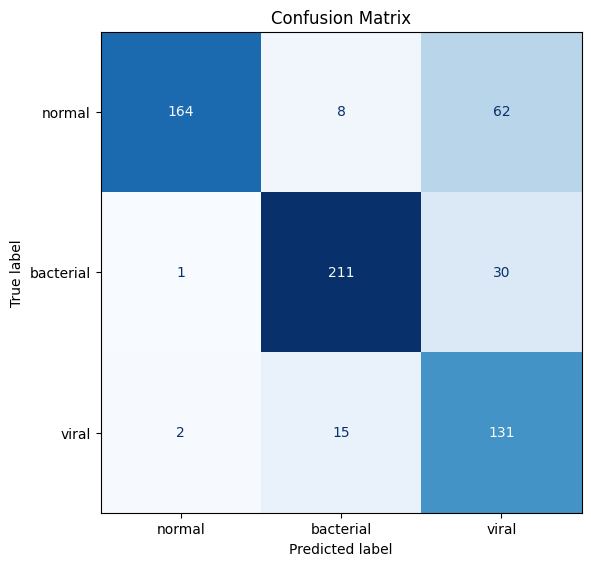

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix,
    display_labels=class_names
)

disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [6]:
df = pd.read_csv("./cnn_model_selection.csv")

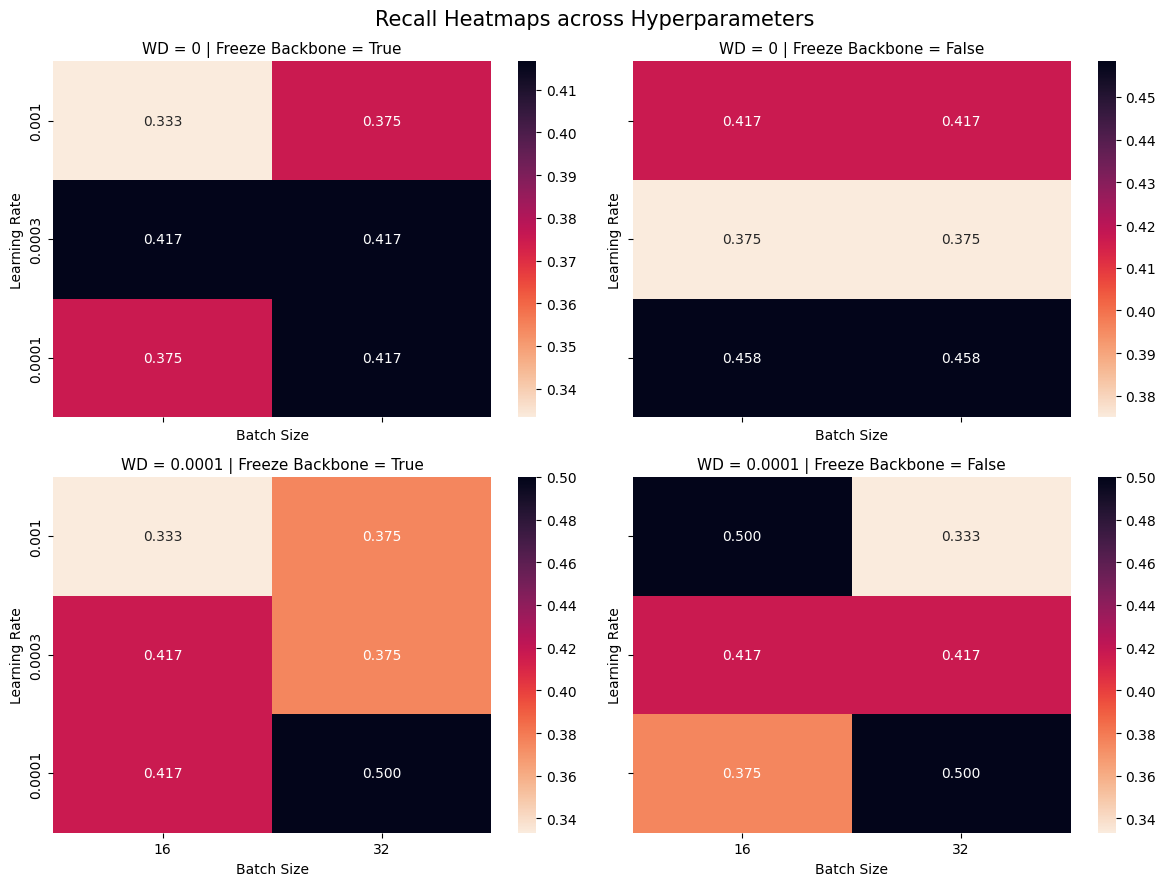

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)

plot_configs = [
    {"weight_decay": 0,      "freeze_backbone": True,  "ax": axes[0, 0]},
    {"weight_decay": 0,      "freeze_backbone": False, "ax": axes[0, 1]},
    {"weight_decay": 0.0001, "freeze_backbone": True,  "ax": axes[1, 0]},
    {"weight_decay": 0.0001, "freeze_backbone": False, "ax": axes[1, 1]}
]

for config in plot_configs:
    wd = config["weight_decay"]
    freeze = config["freeze_backbone"]
    ax = config["ax"]

    subset = df[(df["weight_decay"] == wd) & (df["freeze_backbone"] == freeze)]
    
    pivot = subset.pivot_table(
        values="val_macro_recall",
        index="learning_rate",
        columns="batch_size"
    )

    pivot = pivot.sort_index(ascending=False)

    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="rocket_r", ax=ax)
    
    ax.set_title(f"WD = {wd} | Freeze Backbone = {freeze}", fontsize=11)
    ax.set_ylabel("Learning Rate")
    ax.set_xlabel("Batch Size")

plt.suptitle("Recall Heatmaps across Hyperparameters", fontsize=15, y=0.98)

plt.tight_layout()
plt.show()